## Step 0: Load Dataset from Kaggle in Google Colab

In [ ]:
# Install kagglehub
!pip install kagglehub

# Import library
import kagglehub
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Dataset path:", path)

# Load the CSV file
df = pd.read_csv(path + "/heart_disease_uci.csv")

# Preview data
df.head()

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Dataset path: /kaggle/input/heart-disease-data


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Task A — Data Quality and Preprocessing

### A1 — Identify Missing Values, Duplicates, and Outliers


In [ ]:
# Shape of dataset
df.shape

# Column names
df.columns

# Data types
df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

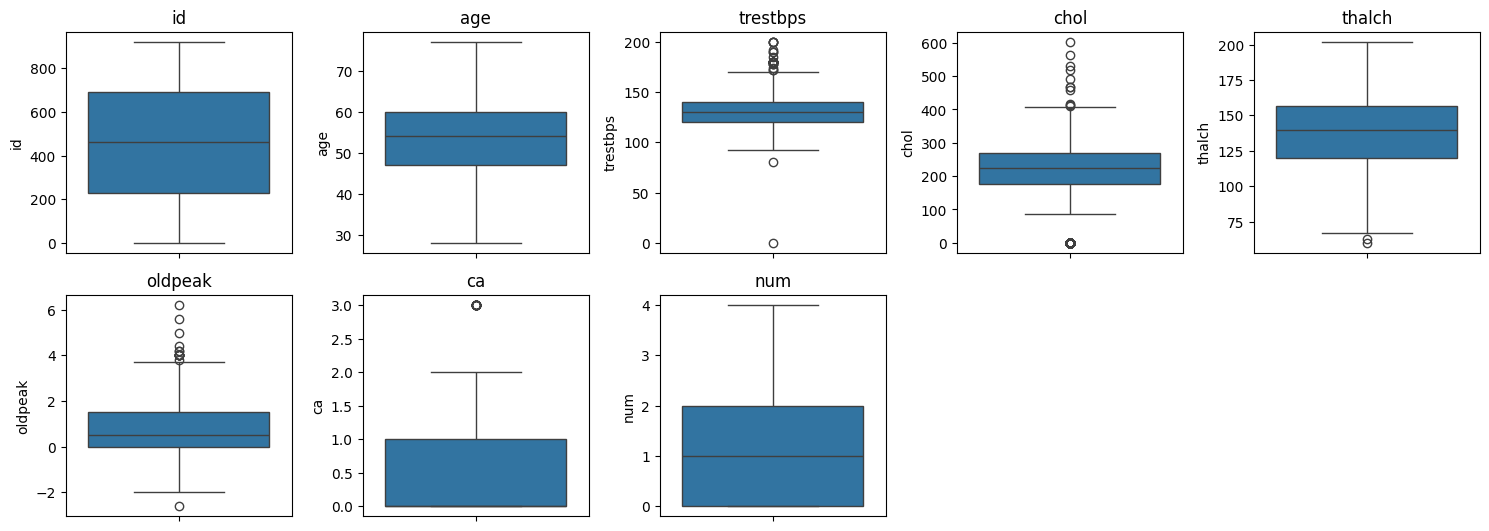

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(3,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### A2 — Attribute Types

| Feature              | Attribute Type       |
| -------------------- | -------------------- |
| age                  | Numeric (Continuous) |
| sex                  | Nominal              |
| dataset              | Nominal              |
| cp (chest pain type) | Nominal              |
| trestbps             | Numeric (Continuous) |
| chol                 | Numeric (Continuous) |
| fbs                  | Nominal              |
| restecg              | Nominal              |
| thalch               | Numeric (Continuous) |
| exang                | Nominal              |
| oldpeak              | Numeric (Continuous) |
| slope                | Ordinal              |
| ca                   | Numeric (Discrete)   |
| thal                 | Nominal              |
| num                  | Target variable      |


### A3 — Data Preprocessing

In [ ]:
df = df.drop(columns=['id'], errors='ignore')

In [ ]:
df['num'] = df['num'].apply(lambda x: 0 if x==0 else 1)

In [ ]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64','float64']).columns

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

In [ ]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('num', axis=1)
y = df['num']

X_scaled = scaler.fit_transform(X)

### A4 — Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Task B — Model Training + Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

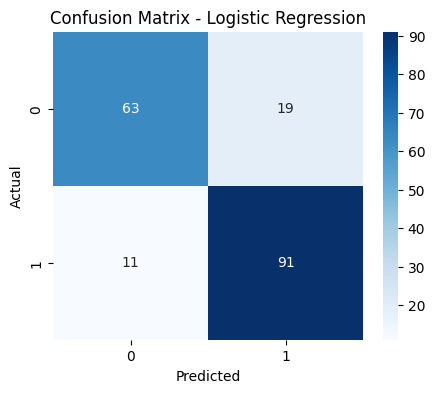

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Performance")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1 Score:", f1_log)
print("ROC AUC:", roc_auc_log)

Logistic Regression Performance
Accuracy: 0.8369565217391305
Precision: 0.8272727272727273
Recall: 0.8921568627450981
F1 Score: 0.8584905660377359
ROC AUC: 0.9214490674318507


In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

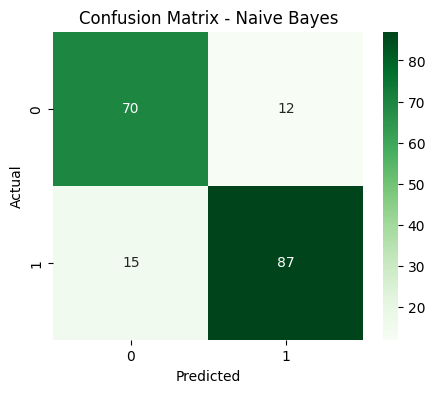

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_prob_nb)

print("Naive Bayes Performance")
print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1 Score:", f1_nb)
print("ROC AUC:", roc_auc_nb)

Naive Bayes Performance
Accuracy: 0.8532608695652174
Precision: 0.8787878787878788
Recall: 0.8529411764705882
F1 Score: 0.8656716417910447
ROC AUC: 0.904830224772836


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy_log, accuracy_nb],
    "Precision": [precision_log, precision_nb],
    "Recall": [recall_log, recall_nb],
    "F1 Score": [f1_log, f1_nb],
    "ROC AUC": [roc_auc_log, roc_auc_nb]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491,0.921449
1,Naive Bayes,0.853261,0.878788,0.852941,0.865672,0.904830


## Task C - Decision Tree Learning + Interpretation

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

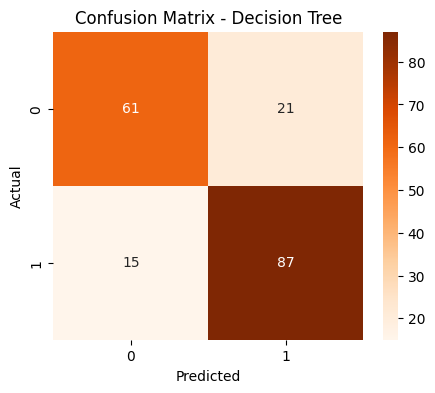

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
print("ROC AUC:", roc_auc_dt)

Decision Tree Performance
Accuracy: 0.8043478260869565
Precision: 0.8055555555555556
Recall: 0.8529411764705882
F1 Score: 0.8285714285714286
ROC AUC: 0.87948350071736


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
16,exang_True,0.420500
2,chol,0.218109
0,age,0.118076
10,cp_atypical angina,0.071776
3,thalch,0.049760
6,sex_Male,0.044737
19,thal_normal,0.026649
4,oldpeak,0.021913
8,dataset_Switzerland,0.014151
11,cp_non-anginal,0.010911


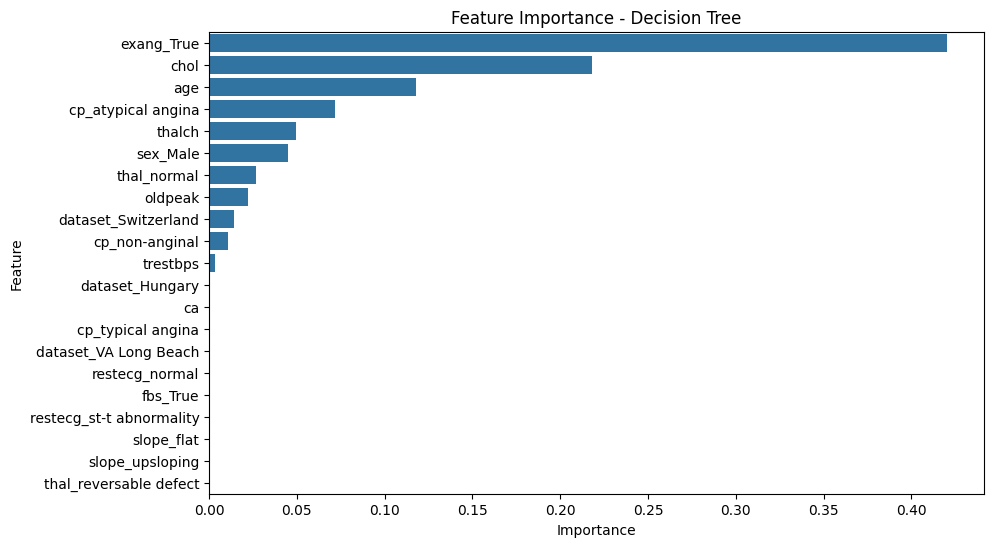

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance - Decision Tree")
plt.show()

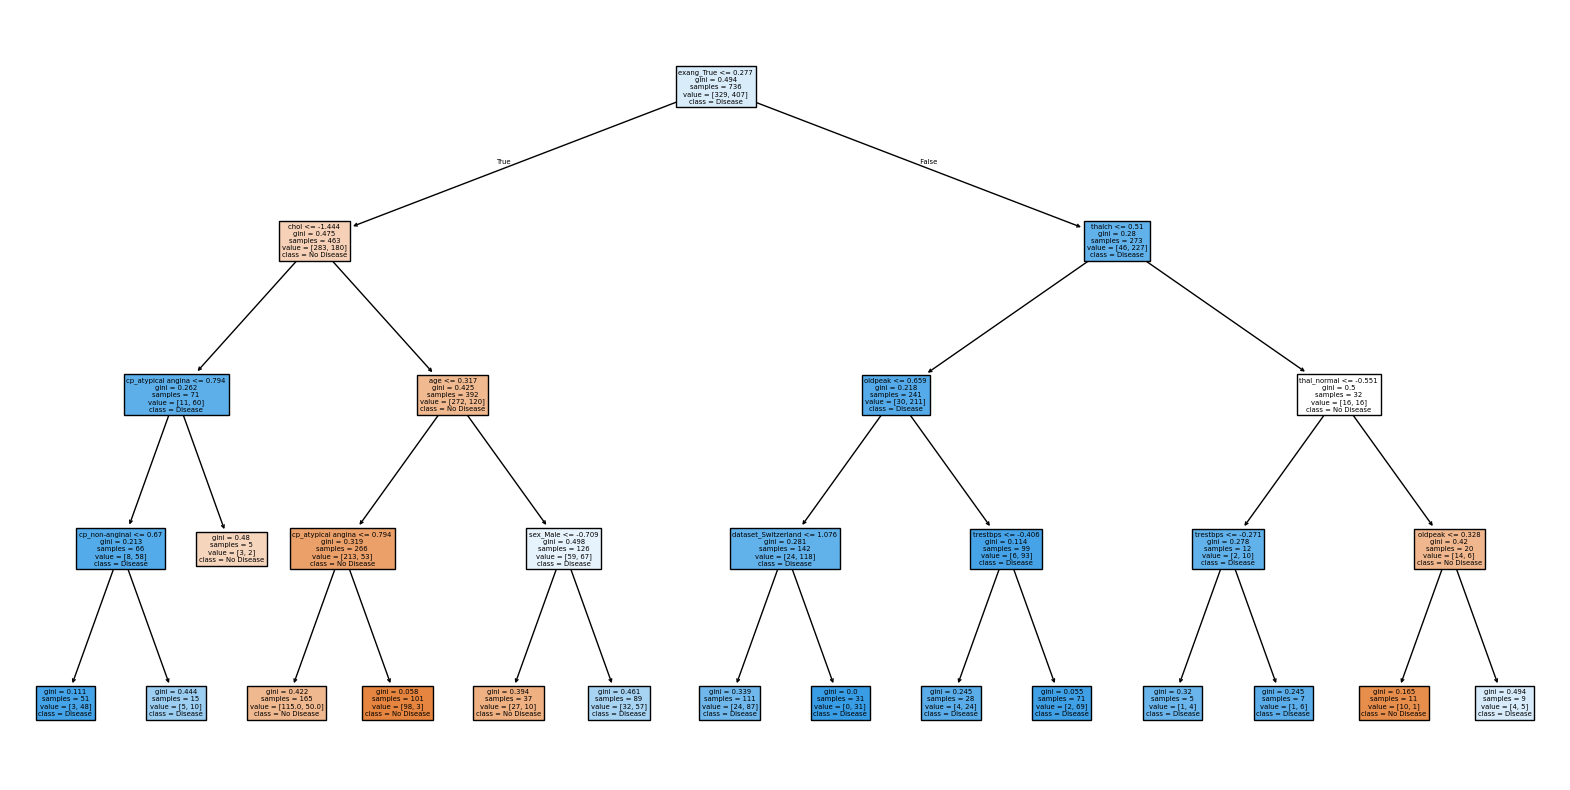

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True
)

plt.show()

## Task D - Rule-Based Classification

In [ ]:
from sklearn.tree import export_text

In [ ]:
tree_rules = export_text(dt_model, feature_names=list(X.columns))

print(tree_rules)

|--- exang_True <= 0.28
|   |--- chol <= -1.44
|   |   |--- cp_atypical angina <= 0.79
|   |   |   |--- cp_non-anginal <= 0.67
|   |   |   |   |--- class: 1.0
|   |   |   |--- cp_non-anginal >  0.67
|   |   |   |   |--- class: 1.0
|   |   |--- cp_atypical angina >  0.79
|   |   |   |--- class: 0.0
|   |--- chol >  -1.44
|   |   |--- age <= 0.32
|   |   |   |--- cp_atypical angina <= 0.79
|   |   |   |   |--- class: 0.0
|   |   |   |--- cp_atypical angina >  0.79
|   |   |   |   |--- class: 0.0
|   |   |--- age >  0.32
|   |   |   |--- sex_Male <= -0.71
|   |   |   |   |--- class: 0.0
|   |   |   |--- sex_Male >  -0.71
|   |   |   |   |--- class: 1.0
|--- exang_True >  0.28
|   |--- thalch <= 0.51
|   |   |--- oldpeak <= 0.66
|   |   |   |--- dataset_Switzerland <= 1.08
|   |   |   |   |--- class: 1.0
|   |   |   |--- dataset_Switzerland >  1.08
|   |   |   |   |--- class: 1.0
|   |   |--- oldpeak >  0.66
|   |   |   |--- trestbps <= -0.41
|   |   |   |   |--- class: 1.0
|   |   |   |--

## Task E - kNN (Lazy Learning)  

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k_values = [1,3,5,7,9]

knn_results = []

for k in k_values:

    knn_model = KNeighborsClassifier(n_neighbors=k)

    knn_model.fit(X_train, y_train)

    y_pred = knn_model.predict(X_test)
    y_prob = knn_model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    knn_results.append([k, acc, prec, rec, f1, roc])

In [ ]:
knn_results_df = pd.DataFrame(knn_results, columns=[
    "k",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
])

knn_results_df

,k,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.755435,0.782178,0.774510,0.778325,0.753109
1,3,0.864130,0.859813,0.901961,0.880383,0.897298
2,5,0.858696,0.839286,0.921569,0.878505,0.897597
3,7,0.869565,0.861111,0.911765,0.885714,0.905129
4,9,0.869565,0.867925,0.901961,0.884615,0.914335


In [ ]:
metrics = ["euclidean","manhattan"]

metric_results = []

for metric in metrics:

    knn_model = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn_model.fit(X_train, y_train)

    y_pred = knn_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    metric_results.append([metric, acc])

In [ ]:
metric_results_df = pd.DataFrame(metric_results, columns=[
    "Distance Metric",
    "Accuracy"
])

metric_results_df

,Distance Metric,Accuracy
0,euclidean,0.858696
1,manhattan,0.858696


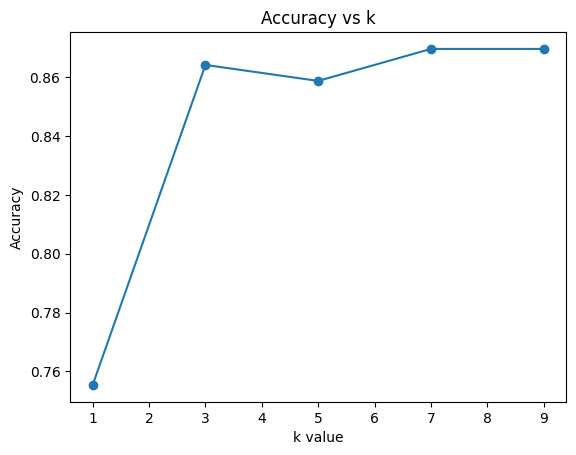

In [ ]:
import matplotlib.pyplot as plt

plt.plot(knn_results_df["k"], knn_results_df["Accuracy"], marker="o")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.show()

## Task F - Ensemble Learning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("ROC AUC:", roc_rf)

Random Forest Performance
Accuracy: 0.8586956521739131
Precision: 0.8454545454545455
Recall: 0.9117647058823529
F1 Score: 0.8773584905660378
ROC AUC: 0.917144906743185


In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [ ]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Performance")
print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)
print("ROC AUC:", roc_gb)

Gradient Boosting Performance
Accuracy: 0.8369565217391305
Precision: 0.8333333333333334
Recall: 0.8823529411764706
F1 Score: 0.8571428571428571
ROC AUC: 0.9145145863223338


In [ ]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

accuracy_ada = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", accuracy_ada)

AdaBoost Accuracy: 0.842391304347826


In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "kNN",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_log,
        accuracy_nb,
        accuracy_dt,
        knn_results_df["Accuracy"].max(),
        accuracy_rf,
        accuracy_gb
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.836957
1,Naive Bayes,0.853261
2,Decision Tree,0.804348
3,kNN,0.869565
4,Random Forest,0.858696
5,Gradient Boosting,0.836957


## Task G - Final Comparison + Recommendation

In [ ]:
final_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "kNN (k=7)",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_log,
        accuracy_nb,
        accuracy_dt,
        knn_results_df["Accuracy"].max(),
        accuracy_rf,
        accuracy_gb
    ],

    "F1 Score":[
        f1_log,
        f1_nb,
        f1_dt,
        knn_results_df["F1 Score"].max(),
        f1_rf,
        f1_gb
    ],

    "Notes":[
        "Baseline linear model",
        "Probabilistic baseline classifier",
        "Interpretable rule-based tree",
        "Distance-based lazy learner",
        "Ensemble of decision trees",
        "Boosting ensemble model"
    ]
})

final_results

,Model,Accuracy,F1 Score,Notes
0,Logistic Regression,0.836957,0.858491,Baseline linear model
1,Naive Bayes,0.853261,0.865672,Probabilistic baseline classifier
2,Decision Tree,0.804348,0.828571,Interpretable rule-based tree
3,kNN (k=7),0.869565,0.885714,Distance-based lazy learner
4,Random Forest,0.858696,0.877358,Ensemble of decision trees
5,Gradient Boosting,0.836957,0.857143,Boosting ensemble model
